In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv(r"C:\Users\ELCOT\Downloads\student.csv")
print(df)

     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72         

In [4]:
 
df["Average"] = (df["math score"] +df["reading score"] +df["writing score"]) / 3
print(df["Average"])

0      72.666667
1      82.333333
2      92.666667
3      49.333333
4      76.333333
         ...    
995    94.000000
996    57.333333
997    65.000000
998    74.333333
999    83.000000
Name: Average, Length: 1000, dtype: float64


In [5]:
def grade(avg):
    if avg >= 90:
        return "A+"
    elif avg >= 80:
        return "A"
    elif avg >= 70:
        return "B"
    elif avg >= 60:
        return "C"
    elif avg >= 50:
        return "D"
    else:
        return "F"

df["Grade"] = df["Average"].apply(grade)
print(df["Grade"])

0       B
1       A
2      A+
3       F
4       B
       ..
995    A+
996     D
997     C
998     B
999     A
Name: Grade, Length: 1000, dtype: str


In [6]:
def result(row):
    if (
        row["math score"] >= 40 and
        row["reading score"] >= 40 and
        row["writing score"] >= 40
    ):
        return "Pass"
    return "Fail"

df["Result"] = df.apply(result, axis=1)
print(df["Result"])

0      Pass
1      Pass
2      Pass
3      Pass
4      Pass
       ... 
995    Pass
996    Pass
997    Pass
998    Pass
999    Pass
Name: Result, Length: 1000, dtype: str


In [7]:
top_10 = df.sort_values(by="Average", ascending=False).head(10)
weak_10 = df.sort_values(by="Average").head(10)

print("\n===== TOP 10 STUDENTS =====")
print(top_10[[
    "math score",
    "reading score",
    "writing score",
    "Average",
    "Grade"
]])

print("\n===== WEAK 10 STUDENTS =====")
print(weak_10[[
    "math score",
    "reading score",
    "writing score",
    "Average",
    "Grade"
]])


===== TOP 10 STUDENTS =====
     math score  reading score  writing score     Average Grade
916         100            100            100  100.000000    A+
962         100            100            100  100.000000    A+
458         100            100            100  100.000000    A+
114          99            100            100   99.666667    A+
712          98            100             99   99.000000    A+
179          97            100            100   99.000000    A+
165          96            100            100   98.666667    A+
625         100             97             99   98.666667    A+
685          94             99            100   97.666667    A+
903          93            100            100   97.666667    A+

===== WEAK 10 STUDENTS =====
     math score  reading score  writing score    Average Grade
59            0             17             10   9.000000     F
980           8             24             23  18.333333     F
596          30             24             15  2

In [8]:
print("\n===== OVERALL STATISTICS =====")
print(df[[
    "math score",
    "reading score",
    "writing score",
    "Average"
]].describe())


===== OVERALL STATISTICS =====
       math score  reading score  writing score      Average
count  1000.00000    1000.000000    1000.000000  1000.000000
mean     66.08900      69.169000      68.054000    67.770667
std      15.16308      14.600192      15.195657    14.257326
min       0.00000      17.000000      10.000000     9.000000
25%      57.00000      59.000000      57.750000    58.333333
50%      66.00000      70.000000      69.000000    68.333333
75%      77.00000      79.000000      79.000000    77.666667
max     100.00000     100.000000     100.000000   100.000000


In [9]:
subject_avg = {
    "Math": df["math score"].mean(),
    "Reading": df["reading score"].mean(),
    "Writing": df["writing score"].mean()
}

print("\n===== SUBJECT-WISE AVERAGE =====")
for sub, avg in subject_avg.items():
    print(f"{sub}: {avg:.2f}")



===== SUBJECT-WISE AVERAGE =====
Math: 66.09
Reading: 69.17
Writing: 68.05


In [21]:
gender_perf = df.groupby("gender")["Average"].mean()

print("\n===== GENDER-WISE AVERAGE =====")
print(gender_perf)



===== GENDER-WISE AVERAGE =====
gender
female    69.569498
male      65.837483
Name: Average, dtype: float64


In [10]:
print("\n===== GRADE DISTRIBUTION =====")
print(df["Grade"].value_counts())


===== GRADE DISTRIBUTION =====
Grade
B     261
C     256
D     182
A     146
F     103
A+     52
Name: count, dtype: int64


In [11]:
print("\n===== RESULT SUMMARY =====")
print(df["Result"].value_counts())



===== RESULT SUMMARY =====
Result
Pass    949
Fail     51
Name: count, dtype: int64


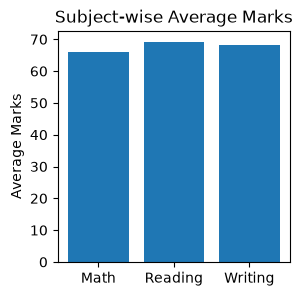

In [12]:
plt.figure(figsize=(3,3))
plt.bar(subject_avg.keys(), subject_avg.values())
plt.title("Subject-wise Average Marks")
plt.ylabel("Average Marks")
plt.show()

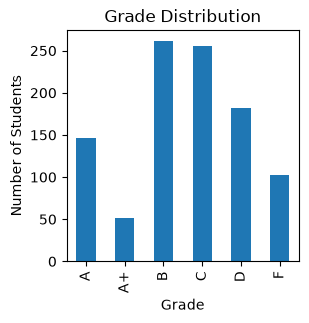

In [13]:
plt.figure(figsize=(3,3))
df["Grade"].value_counts().sort_index().plot(kind="bar")
plt.title("Grade Distribution")
plt.ylabel("Number of Students")
plt.show()

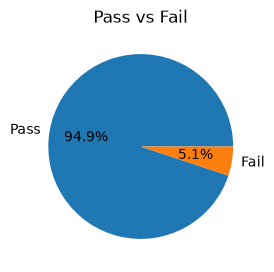

In [14]:
plt.figure(figsize=(3,3))
df["Result"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Pass vs Fail")
plt.ylabel("")
plt.show()

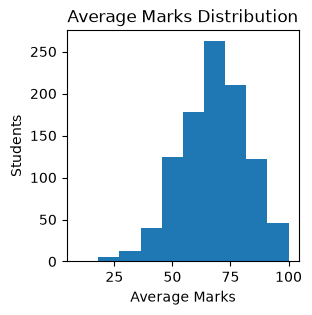

In [15]:
plt.figure(figsize=(3,3))
plt.hist(df["Average"], bins=10)
plt.title("Average Marks Distribution")
plt.xlabel("Average Marks")
plt.ylabel("Students")
plt.show()

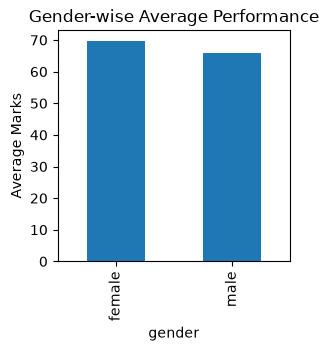

In [20]:

plt.figure(figsize=(3,3))
gender_perf.plot(kind="bar")
plt.title("Gender-wise Average Performance")
plt.ylabel("Average Marks")
plt.show()

In [17]:
df.to_csv("student_performance_report.csv", index=False)
print("\nReport saved as 'student_performance_report.csv'")


Report saved as 'student_performance_report.csv'
